## Top 10 Wines to Highlight
> We selected wines with a minimum of 1000 ratings to ensure statistical reliability, ranked by average rating and popularity

In [1]:
import sqlite3

conn = sqlite3.connect("../data/vivino.db")
cursor = conn.cursor()

with open("../queries/top_10_wines.sql", "r") as f:
    query = f.read()

cursor.execute(query)
print(cursor.fetchall())

[('Cabernet Sauvignon', 4.8, 2941, 'États-Unis'), ('Unico', 4.7, 45140, 'Espagne'), ('Sauternes', 4.7, 44126, 'France'), ('Special Selection Cabernet Sauvignon', 4.7, 41236, 'États-Unis'), ('Pomerol', 4.7, 32157, 'France'), ('Grange', 4.7, 24356, 'Australie'), ('Toscana', 4.7, 16284, 'Italie'), ('Unico Reserva Especial Edición', 4.7, 13025, 'Espagne'), ('Le Mesnil Blanc de Blancs (Cuvée S) Brut Champagne', 4.7, 9564, 'France'), ('Amarone della Valpolicella Classico', 4.7, 8900, 'Italie')]


## Best Country for Marketing Budget
Analysing top 10 countries based on 
- platfrom users
- wine variety
- average wine rating

In [ ]:
import matplotlib.pyplot as plt
import sqlite3

conn = sqlite3.connect("../data/vivino.db")
cursor = conn.cursor()

with open("../queries/best_country.sql", "r") as f:
    query = f.read()

cursor.execute(query)
results = cursor.fetchall()
results

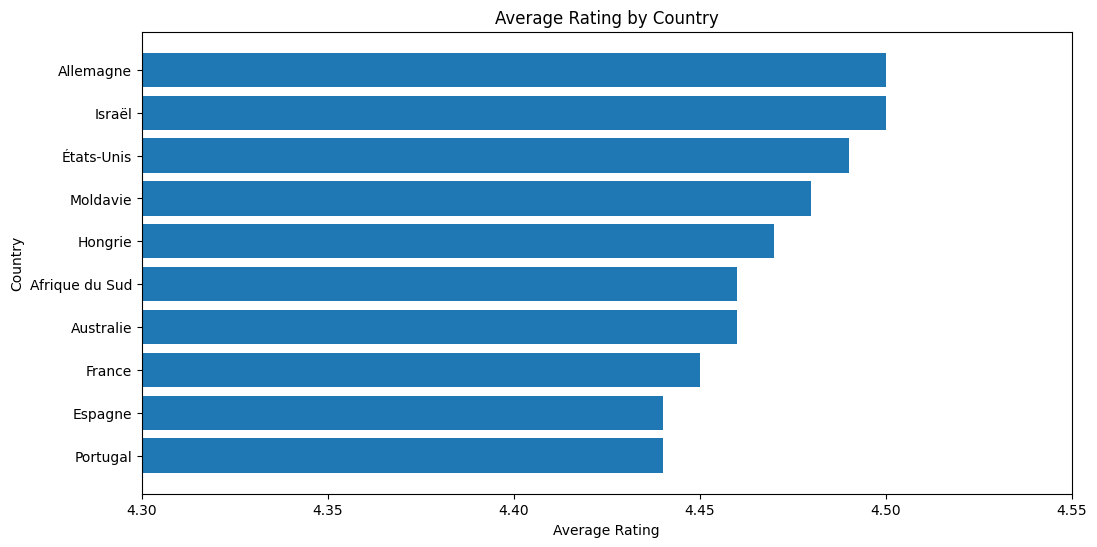

In [7]:
results_sorted = sorted(results, key=lambda x: x[3])
countries = [row[0] for row in results_sorted]
avg_ratings = [row[3] for row in results_sorted]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(countries, avg_ratings)
ax.set_xlim(4.3, 4.55)

ax.set_title("Average Rating by Country")
ax.set_xlabel("Average Rating")
ax.set_ylabel("Country")

plt.show()

### Conclusion
Based on our analysis of the top 10 countries by average wine rating, we recommend prioritising the United States for our marketing budget. With over 12.3 million users on the platform nearly double the second largest market (France at 5.9M). The US represents the largest addressable audience. Combined with 204,000 wines and a strong average rating of 4.49, the US market offers both reach and quality. While Germany leads slightly in average rating (4.50), its user base is 5x smaller, making the US the stronger choice for maximising marketing impact.
> Recommendation : USA

## Best Wineries. 3 Awards
We will award 3 wineries.
- Best Overall Winery
- Most International
- Most Diverse

In [5]:
# Best Winery

import sqlite3

conn = sqlite3.connect("../data/vivino.db")
cursor = conn.cursor()

with open("../queries/best_winery_award.sql", "r") as f:
    query = f.read()

cursor.execute(query)
print(cursor.fetchall())

[(1337, 5, 4.64), (11601, 8, 4.63), (1235, 5, 4.6)]


In [8]:
# Most international

import sqlite3

conn = sqlite3.connect("../data/vivino.db")
cursor = conn.cursor()

with open("../queries/most_international_winery_award.sql", "r") as f:
    query = f.read()

cursor.execute(query)
print(cursor.fetchall())

[(9294, 10), (1358, 7), (11601, 5)]


In [7]:
# Most diverse

import sqlite3

conn = sqlite3.connect("../data/vivino.db")
cursor = conn.cursor()

with open("../queries/most_diverse_winery_award.sql", "r") as f:
    query = f.read()

cursor.execute(query)
print(cursor.fetchall())

[(10474, 12), (9294, 10), (1252, 9)]


### Conclusion
Because of data issues with the wineries table, winery names were identified manually.
SELECT name FROM vintages
WHERE wine_id IN (
    SELECT id FROM wines WHERE winery_id = 'wine id'
)
LIMIT 5;

> Best Overall Winery "Krug" (id: 1337)

> Most International "Domaine Faiveley" (id: 9294) with 10 regions

> Most diverse "Gaja" (id: 10474) with !2 different wines

## Wines With All Keywords
- coffee
- toast
- green apple
- cream
- citrus 

In [9]:
import sqlite3

conn = sqlite3.connect("../data/vivino.db")
cursor = conn.cursor()

with open("../queries/taste_keyword.sql", "r") as f:
    query = f.read()

cursor.execute(query)
print(cursor.fetchall())

[('La Grande Année Brut Champagne', 'non_oak', 5), ('Cristal Brut Champagne (Millésimé)', 'non_oak', 5), ('Belle Epoque Brut Champagne', 'tree_fruit', 5), ('Vintage', 'non_oak', 5), ('La Grande Dame Brut Champagne', 'non_oak', 5), ('Brut Champagne', 'non_oak', 5), ("Trebbiano d'Abruzzo", 'oak', 5), ('Le Mesnil Blanc de Blancs (Cuvée S) Brut Champagne', 'citrus_fruit', 5), ('Comtes de Champagne Blanc de Blancs', 'non_oak', 5), ('Sauternes', 'tree_fruit', 5), ('R.D Extra Brut Champagne (Récemment Dégorgé)', 'non_oak', 5), ('Dom Ruinart Blanc de Blancs Brut Champagne', 'non_oak', 5), ('Blanc des Millénaires', 'non_oak', 5), ('Sir Winston Churchill Brut Champagne', 'non_oak', 5), ('P2 Plénitude Brut Champagne', 'non_oak', 5), ('Cuvée des Enchanteleurs Brut Champagne', 'non_oak', 5), ('Grande Cuvée', 'non_oak', 5)]


### Conclusion
All keywords are found mostly in premium champagnes

## Top 3 Most Common Grapes
Select wines that are easy to find all around the world. Give 5 best rated wines for each grape.